In [2]:
!hf auth login



    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: fineGrained).
The token `Tin12` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `Tin12`


In [3]:
import pandas as pd

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
file_path = '/content/drive/MyDrive/A2/data/a2_test.csv'
df = pd.read_csv(file_path)

df.head()


,rewire_id,text,label_category
0,sexism2022_english-11647,She may be worth what someone paid for her in ...,derogation
1,sexism2022_english-15883,The men who white knight for women eventually ...,prejudiced
2,sexism2022_english-12494,Two thoughts to keep in mind about women and A...,derogation
3,sexism2022_english-26,"Wimmin. No matter how good they have it, they'...",prejudiced
4,sexism2022_english-7475,"So just a few months ago, while Republican wom...",prejudiced


In [6]:
!pip install -q -U torch transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 576.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/90.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170

In [7]:
import torch
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig


torch.cuda.empty_cache()
gc.collect()

60

In [8]:
def load_quantized_model(model_id):

    print(f"\n{'='*40}")
    print(f"Processing model {model_id}")
    print(f"{'='*40}")


    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16
    )


    print("1. Loading Model Weights...")
    try:
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
            low_cpu_mem_usage=True
        )
    except Exception as e:
        print(f"Error loading model: {e}")
        return None, None


    print("2. Loading Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        trust_remote_code=True
    )


    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

        if hasattr(model.config, 'pad_token_id') and model.config.pad_token_id is None:
             model.config.pad_token_id = tokenizer.eos_token_id

    print(f"Successfully loaded: {model_id}")
    return model, tokenizer

In [9]:
model_id_1 = "mistralai/Mistral-7B-Instruct-v0.3"
model_id_2 = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"

In [10]:
#model 1: Mistral v3


model_mistral, tokenizer_mistral = load_quantized_model(model_id_1)


print(model_mistral)


Processing model mistralai/Mistral-7B-Instruct-v0.3
1. Loading Model Weights...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/587k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Successfully loaded: mistralai/Mistral-7B-Instruct-v0.3
MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm):

In [11]:
# Clear GPU memory

del model_mistral
del tokenizer_mistral
torch.cuda.empty_cache()
gc.collect()
print("GPU memory cleared. Ready to load the next model...")

GPU memory cleared. Ready to load the next model...


In [12]:
#model 2: DeepSeek R1


model_deepseek, tokenizer_deepseek = load_quantized_model(model_id_2)




Processing model deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
1. Loading Model Weights...


config.json:   0%|          | 0.00/680 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-000002.safetensors:   0%|          | 0.00/6.62G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

2. Loading Tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Successfully loaded: deepseek-ai/DeepSeek-R1-Distill-Qwen-7B


In [13]:
import pandas as pd
import numpy as np
import os

# Loading Data
try:
    df_test = pd.read_csv(file_path)
    print("a2_test.csv loaded successfully.")
except FileNotFoundError:
    print("File 'a2_test.csv' not found. Please adjust the path.")
    raise

# Extracting texts
TEST_TEXTS = df_test['text'].tolist()
print(f"Total texts to classify (TEST_TEXTS): {len(TEST_TEXTS)}")


a2_test.csv loaded successfully.
Total texts to classify (TEST_TEXTS): 300


In [14]:
# Prompt Definition
from typing import List, Dict
import re
import torch

# Prompt template (assignment)
A2_PROMPT_TEMPLATE_DICT: List[Dict] = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        TEXT: {text}

        ANSWER:
        """
    }
]

In [15]:
# Prompt Preparation
def prepare_prompts(texts: List[str], prompt_template: List[Dict], tokenizer) -> List[torch.Tensor]:
  """
    This function formats input text samples into instructions prompts
    and tokenizes them into input IDs, ready for the LLM.

    Inputs:
      texts: input texts to classify via prompting (List[str])
      prompt_template: the prompt template provided in this assignment (List[Dict])
      tokenizer: the transformers Tokenizer object instance associated
      with the chosen model card

    Outputs:
      input texts to classify in the form of tokenized instruction prompts (List[torch.Tensor])
  """

  tokenized_prompts = []

  for text in texts:
    current_prompt = [d.copy() for d in prompt_template]

    current_prompt[1]['content'] = current_prompt[1]['content'].format(text=text)

    # Tokenize structured conversation
    input_ids = tokenizer.apply_chat_template(
        current_prompt,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    )

    tokenized_prompts.append(input_ids.squeeze(0))

  return tokenized_prompts

In [16]:
# Response Generation (Part 1)
def generate_responses(model, prompt_examples: List[torch.Tensor]) -> List[str]:
    """
    This function implements the inference loop for a LLM model.
    """

    raw_responses = []
    device = model.device

    # Tokenizer for current model
    if 'model_mistral' in globals() and model is model_mistral:
        tokenizer = tokenizer_mistral
    elif 'model_ds' in globals() and model is model_ds:
        tokenizer = tokenizer_ds
    else:
        tokenizer = AutoTokenizer.from_pretrained(model.config._name_or_path)


    GEN_PARAMS = {
        "max_new_tokens": 10,
        "do_sample": False,
        "pad_token_id": tokenizer.eos_token_id,
    }

    print(f"Generating {len(prompt_examples)} responses on device: {device}...")

    for i, input_id_tensor in enumerate(prompt_examples):

        input_id_tensor = input_id_tensor.unsqueeze(0).to(device)

        output_ids = model.generate(
            input_id_tensor,
            **GEN_PARAMS
        )

        # Decode output
        generated_text = tokenizer.decode(
            output_ids[0, input_id_tensor.shape[-1]:],
            skip_special_tokens=True
        ).strip()

        raw_responses.append(generated_text)

    return raw_responses

In [17]:
# Response Processing (Part 2)

import re

def process_response(response: str) -> int:
  """
    This function processes a raw text response generated by the LLM
    and maps the response to an integer label.

    Updated to handle DeepSeek R1's <think> tags.
  """
  LABEL_MAPPING = {
    'not-sexist': 0,
    'threats': 1,
    'derogation': 2,
    'animosity': 3,
    'prejudiced': 4,
    'prejudiced discussion': 4
  }
  # 1. Strip <think>...</think> block
  clean_text = response
  if "</think>" in response:
      parts = response.split("</think>")
      if len(parts) > 1:
          clean_text = parts[-1]

  clean_text = clean_text.lower().strip()
  clean_text = re.sub(r'[\'"]|[.,!?;]', '', clean_text)

  # 2. Valid labels in remaining text
  valid_labels_regex = r'\b(' + '|'.join([re.escape(k) for k in LABEL_MAPPING.keys()]) + r')\b'
  matches = re.findall(valid_labels_regex, clean_text)

  if matches:
    # Last label
    final_label_text = matches[-1]

    if 'discussion' in final_label_text:
        final_label_text = 'prejudiced'

    return LABEL_MAPPING.get(final_label_text, 0)

  # Fallback: If no label found
  if clean_text != response.lower().strip():
      clean_text_fallback = response.lower().strip()
      clean_text_fallback = re.sub(r'[\'"]|[.,!?;]', '', clean_text_fallback)
      matches_fallback = re.findall(valid_labels_regex, clean_text_fallback)
      if matches_fallback:
          # Absolute last match from string
          final_label_text = matches_fallback[-1]
          if 'discussion' in final_label_text:
             final_label_text = 'prejudiced'
          return LABEL_MAPPING.get(final_label_text, 0)

  return 0

In [18]:
# Reloading Mistral model and tokenizer
model_mistral, tokenizer_mistral = load_quantized_model(model_id_1)

tokenizer_mistral.padding_side = "left"
tokenizer_mistral.pad_token = tokenizer_mistral.eos_token




Processing model mistralai/Mistral-7B-Instruct-v0.3
1. Loading Model Weights...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

2. Loading Tokenizer...
Successfully loaded: mistralai/Mistral-7B-Instruct-v0.3


In [19]:
import torch
from collections import Counter
import transformers

# Mistral Inference

# Tokenizer Padding: Left
if hasattr(tokenizer_mistral, "padding_side"):
    tokenizer_mistral.padding_side = "left"
    tokenizer_mistral.pad_token = tokenizer_mistral.eos_token
elif tokenizer_mistral.pad_token is None:
    tokenizer_mistral.pad_token = tokenizer_mistral.eos_token
    tokenizer_mistral.padding_side = "left"
else:
    transformers.AutoTokenizer.from_pretrained = lambda *args, **kwargs: (
        __import__("transformers").AutoTokenizer.from_pretrained(
            *args, {**kwargs, "padding_side": "left"}
        )
    )
print("Global tokenizer padding set to LEFT for Mistral")

print("\n Running Inference for MISTRAL ")

# Prompts
mistral_prompts_tensors = prepare_prompts(
    texts=TEST_TEXTS,
    prompt_template=A2_PROMPT_TEMPLATE_DICT,
    tokenizer=tokenizer_mistral
)
print(f"Prepared {len(mistral_prompts_tensors)} tokenized prompts for Mistral.")

# Normalize i/p
input_ids_list = [x.squeeze(0) if isinstance(x, dict) else x for x in mistral_prompts_tensors]
max_length = max(len(ids) for ids in input_ids_list)

padded_input_ids = []
padded_attention_masks = []

for ids in input_ids_list:
    padding_length = max_length - len(ids)
    padded_ids = torch.cat([
        torch.full((padding_length,), tokenizer_mistral.pad_token_id, dtype=ids.dtype),
        ids
    ])
    padded_input_ids.append(padded_ids)

    padded_mask = torch.cat([
        torch.full((padding_length,), 0, dtype=torch.long),
        torch.ones_like(ids, dtype=torch.long)
    ])
    padded_attention_masks.append(padded_mask)

mistral_inputs = {
    "input_ids": torch.stack(padded_input_ids),
    "attention_mask": torch.stack(padded_attention_masks),
}

mistral_inputs = {k: v.to(model_mistral.device) for k, v in mistral_inputs.items()}

# Store raw responses
batch_size = 32
mistral_raw_responses = []

for i in range(0, mistral_inputs["input_ids"].shape[0], batch_size):
    batch_input_ids = mistral_inputs["input_ids"][i:i+batch_size]
    batch_attention_mask = mistral_inputs["attention_mask"][i:i+batch_size]
    input_lengths = [len(x) for x in batch_input_ids]

    with torch.no_grad():
        batch_out = model_mistral.generate(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            max_new_tokens=10,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer_mistral.eos_token_id,
            eos_token_id=tokenizer_mistral.eos_token_id,
        )

    for j in range(batch_out.shape[0]):
        generated_text = tokenizer_mistral.decode(
            batch_out[j, input_lengths[j]:],\
            skip_special_tokens=True
        ).strip()
        mistral_raw_responses.append(generated_text)

# Convert raw model outputs to predicted class labels (zero-shot)
mistral_pred_labels_zero = [process_response(res) for res in mistral_raw_responses]

print(f"Generated {len(mistral_pred_labels_zero)} predicted labels for Mistral.")


# Deepseek Inference

print("\n Running Inference for DEEPSEEK ")

# Tokenizer Padding: Left
if hasattr(tokenizer_deepseek, "padding_side"):
    tokenizer_deepseek.padding_side = "left"
    if tokenizer_deepseek.pad_token is None:
        tokenizer_deepseek.pad_token = tokenizer_deepseek.eos_token
else:
    tokenizer_deepseek.padding_side = "left"
    tokenizer_deepseek.pad_token = tokenizer_deepseek.eos_token

# Prompts
deepseek_prompts_tensors = prepare_prompts(
    texts=TEST_TEXTS,
    prompt_template=A2_PROMPT_TEMPLATE_DICT,
    tokenizer=tokenizer_deepseek
)
print(f"Prepared {len(deepseek_prompts_tensors)} tokenized prompts for DeepSeek.")

# Normalize i/p
input_ids_list_ds = [x.squeeze(0) if isinstance(x, torch.Tensor) else x for x in deepseek_prompts_tensors]
max_length_ds = max(len(ids) for ids in input_ids_list_ds)

padded_input_ids_ds = []
padded_attention_masks_ds = []

for ids in input_ids_list_ds:
    padding_length = max_length_ds - len(ids)
    padded_ids = torch.cat([
        torch.full((padding_length,), tokenizer_deepseek.pad_token_id, dtype=ids.dtype),
        ids
    ])
    padded_input_ids_ds.append(padded_ids)

    padded_mask = torch.cat([
        torch.full((padding_length,), 0, dtype=torch.long),
        torch.ones_like(ids, dtype=torch.long)
    ])
    padded_attention_masks_ds.append(padded_mask)

deepseek_inputs = {
    "input_ids": torch.stack(padded_input_ids_ds),
    "attention_mask": torch.stack(padded_attention_masks_ds),
}

deepseek_inputs = {k: v.to(model_deepseek.device) for k, v in deepseek_inputs.items()}

# Store raw responses
batch_size = 8
deepseek_raw_responses = []

print(f"Processing DeepSeek in batches of {batch_size} (Max tokens: 512)...")
print("This will take longer than Mistral due to the reasoning chain.")

for i in range(0, deepseek_inputs["input_ids"].shape[0], batch_size):
    batch_input_ids = deepseek_inputs["input_ids"][i:i+batch_size]
    batch_attention_mask = deepseek_inputs["attention_mask"][i:i+batch_size]
    input_lengths = [len(x) for x in batch_input_ids]

    with torch.no_grad():
        batch_out = model_deepseek.generate(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            max_new_tokens=512,
            temperature=0.6,
            top_p=0.95,
            do_sample=True,
            pad_token_id=tokenizer_deepseek.eos_token_id,
            eos_token_id=tokenizer_deepseek.eos_token_id,
        )

    for j in range(batch_out.shape[0]):
        # Decode
        generated_text = tokenizer_deepseek.decode(
            batch_out[j, input_lengths[j]:],\
            skip_special_tokens=True
        ).strip()
        deepseek_raw_responses.append(generated_text)

    if (i + batch_size) % 32 == 0 or (i + batch_size) >= 300:
        print(f"  Processed {min(i + batch_size, 300)}/300 samples...")

print("DeepSeek RAW Responses (first 3 samples):")
for i, resp in enumerate(deepseek_raw_responses[:3]):
    print(f"[{i}] {resp[:200]}...")

#  Convert raw model outputs to predicted class labels (zero-shot)
deepseek_pred_labels_zero = [process_response(res) for res in deepseek_raw_responses]

print(f"Generated {len(deepseek_pred_labels_zero)} predicted labels for DeepSeek.")
print("DeepSeek Predictions (first 10):", deepseek_pred_labels_zero[:10])

# Sanity Check
print("\n Label Distribution ")
print("Mistral:", Counter(mistral_pred_labels_zero))
print("DeepSeek:", Counter(deepseek_pred_labels_zero))

Global tokenizer padding set to LEFT for Mistral

 Running Inference for MISTRAL 
Prepared 300 tokenized prompts for Mistral.
Generated 300 predicted labels for Mistral.

 Running Inference for DEEPSEEK 
Prepared 300 tokenized prompts for DeepSeek.
Processing DeepSeek in batches of 8 (Max tokens: 512)...
This will take longer than Mistral due to the reasoning chain.
  Processed 32/300 samples...
  Processed 64/300 samples...
  Processed 96/300 samples...
  Processed 128/300 samples...
  Processed 160/300 samples...
  Processed 192/300 samples...
  Processed 224/300 samples...
  Processed 256/300 samples...
  Processed 288/300 samples...
  Processed 300/300 samples...
DeepSeek RAW Responses (first 3 samples):
[0] Alright, I'm looking at this text: "She may be worth what someone paid for her in terms of stimulating walking away." The user wants me to classify it as not-sexist or sexist, and if it's sexist, then...
[1] Okay, so I need to determine if the given text is not-sexist or if it 

In [20]:

print("Tokenizer class:", type(tokenizer_deepseek))
print("Model class:", type(model_deepseek))
print("Special tokens:", tokenizer_deepseek.special_tokens_map)


Tokenizer class: <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>
Model class: <class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>
Special tokens: {'bos_token': '<｜begin▁of▁sentence｜>', 'eos_token': '<｜end▁of▁sentence｜>', 'pad_token': '<｜end▁of▁sentence｜>'}


In [21]:
# Verification and Storage

# Predictions
print("\nVerification of Final Output ")
print(f"Mistral Predictions (first 10): {mistral_pred_labels_zero[:10]}")
print(f"DeepSeek Predictions (first 10): {deepseek_pred_labels_zero[:10]}")

TRUE_LABELS = df_test['label_category'].apply(process_response).tolist()
print(f"True Labels size: {len(TRUE_LABELS)}")

# Storing
np.save('mistral_predictions.npy', np.array(mistral_pred_labels_zero))
np.save('deepseek_predictions.npy', np.array(deepseek_pred_labels_zero))

print("\n Execution complete. ")


Verification of Final Output 
Mistral Predictions (first 10): [3, 4, 3, 4, 4, 4, 3, 4, 3, 0]
DeepSeek Predictions (first 10): [0, 3, 2, 2, 4, 4, 3, 2, 0, 0]
True Labels size: 300

 Execution complete. 


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

mistral_accuracy = accuracy_score(TRUE_LABELS, mistral_pred_labels_zero)

mistral_precision = precision_score(TRUE_LABELS, mistral_pred_labels_zero, average='weighted', zero_division=0)

mistral_recall = recall_score(TRUE_LABELS, mistral_pred_labels_zero, average='weighted', zero_division=0)

mistral_f1_score = f1_score(TRUE_LABELS, mistral_pred_labels_zero, average='weighted', zero_division=0)

# Results
print(f"Mistral Model Performance:")
print(f"  Accuracy: {mistral_accuracy:.4f}")
print(f"  Precision: {mistral_precision:.4f}")
print(f"  Recall: {mistral_recall:.4f}")
print(f"  F1-score: {mistral_f1_score:.4f}")

Mistral Model Performance:
  Accuracy: 0.3867
  Precision: 0.5395
  Recall: 0.3867
  F1-score: 0.3716


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

deepseek_accuracy = accuracy_score(TRUE_LABELS, deepseek_pred_labels_zero)

deepseek_precision = precision_score(TRUE_LABELS, deepseek_pred_labels_zero, average='weighted', zero_division=0)

deepseek_recall = recall_score(TRUE_LABELS, deepseek_pred_labels_zero, average='weighted', zero_division=0)

deepseek_f1_score = f1_score(TRUE_LABELS, deepseek_pred_labels_zero, average='weighted', zero_division=0)

# Results
print(f"DeepSeek Model Performance:")
print(f"  Accuracy: {deepseek_accuracy:.4f}")
print(f"  Precision: {deepseek_precision:.4f}")
print(f"  Recall: {deepseek_recall:.4f}")
print(f"  F1-score: {deepseek_f1_score:.4f}")

DeepSeek Model Performance:
  Accuracy: 0.3300
  Precision: 0.3831
  Recall: 0.3300
  F1-score: 0.3155


In [24]:
from sklearn.metrics import f1_score
import numpy as np

def compute_metrics(y_pred, y_true):

    valid_labels = ['not-sexist', 'threats', 'derogation', 'animosity', 'prejudiced']

    parsed_preds = []
    fail_count = 0

    for response in y_pred:


        pred_id = process_response(response)
        if pred_id == 0:
            clean_text = str(response).lower()
            if not any(lbl in clean_text for lbl in ['not-sexist', 'threats', 'derogation', 'animosity', 'prejudiced']):
                fail_count += 1
        parsed_preds.append(pred_id)


    fail_ratio = fail_count / len(y_pred)


    f1 = f1_score(y_true, parsed_preds, average='macro', zero_division=0)


    return {
        "macro_f1": f1,
        "fail_ratio": fail_ratio
    }

In [25]:
label_map = {
    'not-sexist': 0,
    'threats': 1,
    'derogation': 2,
    'animosity': 3,
    'prejudiced': 4,
    'prejudiced discussion': 4
}


def get_true_label_id(label_str):

    clean_label = str(label_str).lower().strip()

    return label_map.get(clean_label, 0)


y_true = df_test['label_category'].apply(get_true_label_id).tolist()

print(f"Ground truth labels prepared. Total samples {len(y_true)}")
print(f"Preview of first 10 labels {y_true[:10]}")

Ground truth labels prepared. Total samples 300
Preview of first 10 labels [2, 4, 2, 4, 4, 4, 3, 4, 3, 0]


In [26]:
print("Evaluating Mistral Model Performance...")

if 'mistral_raw_responses' in globals():
    # Compute metrics
    mistral_zero = compute_metrics(mistral_raw_responses, y_true)

    # Print results
    print(f"Mistral Macro F1 Score: {mistral_zero['macro_f1']:.4f}")
    print(f"Mistral Fail Ratio:     {mistral_zero['fail_ratio']:.2%}")
else:
    print("Warning: 'mistral_raw_responses' not found.")



print("Evaluating DeepSeek Model Performance...")

if 'deepseek_raw_responses' in globals():
    # Compute metrics
    deepseek_zero = compute_metrics(deepseek_raw_responses, y_true)

    # Print results
    print(f"DeepSeek Macro F1 Score: {deepseek_zero['macro_f1']:.4f}")
    print(f"DeepSeek Fail Ratio:     {deepseek_zero['fail_ratio']:.2%}")
else:
    print("Warning: 'deepseek_raw_responses' not found.")

Evaluating Mistral Model Performance...
Mistral Macro F1 Score: 0.3716
Mistral Fail Ratio:     0.00%
Evaluating DeepSeek Model Performance...
DeepSeek Macro F1 Score: 0.3155
DeepSeek Fail Ratio:     0.00%


In [27]:
df_demo = pd.read_csv('/content/drive/MyDrive/A2/data/demonstrations.csv')

In [28]:
def build_few_shot_demonstrations(demonstrations, num_per_class=2):
    """
    Inputs:
      demonstrations: DataFrame wrapping demonstrations.csv
      num_per_class: number of demonstrations per class (default 2)

    Outputs:
      list of demonstrations to inject into the prompt template.
      (Returns a single string containing all examples)
    """
    target_categories = [
        'not-sexist',
        'threats',
        'derogation',
        'animosity',
        'prejudiced'
    ]

    formatted_examples = []

    for category in target_categories:

        category_df = demonstrations[demonstrations['label_category'] == category]

        n_samples = min(len(category_df), num_per_class)
        samples = category_df.sample(n=n_samples, random_state=42)

        for _, row in samples.iterrows():
            text = row['text']
            label = row['label_category']

            example_str = f"TEXT: {text}\nANSWER: {label}"
            formatted_examples.append(example_str)

    return "\n\n".join(formatted_examples)

In [29]:
few_shot_string = build_few_shot_demonstrations(df_demo, num_per_class=2)
print("Generated Few-shot Examples:\n")
print(few_shot_string)

Generated Few-shot Examples:

TEXT: That joke is 100 times better and more apt than what he said. I'd have laughed at that joke. The one he made was reaaaal crap.
ANSWER: not-sexist

TEXT: I think Torba is afraid of getting sued because people can interpret that tweet as glorifying violence against people? Find another body shot of her where she isn't being run over
ANSWER: not-sexist

TEXT: Two things. 1st is when a woman posts that, she's saying she's ignorant. Ignorance is the lack of awareness. 2nd is a little thug in him is an invitation to slap her around, you know, just a little.
ANSWER: threats

TEXT: I'd just pretend to get locked down, set a wedding date, get her pregnant, then leave the country. Nobody is going to extradite me based on that horseshit allegation.
ANSWER: threats

TEXT: Good Christian Girl > Into Bondage Are you retarded? How is the cognitive dissonance not blowing your mind apart? All women like it rough but the ones in BDSM are damaged beyond belief and comp

In [30]:
from typing import List, Dict
import torch

def prepare_prompts(texts: List[str], prompt_template: List[Dict], tokenizer, demonstrations: str = "") -> List[torch.Tensor]:
  """
    Updated function for Task 5.
    Now accepts 'demonstrations' string to inject into the prompt template.

    Inputs:
      texts: input texts to classify
      prompt_template: the prompt template (containing {examples} and {text} placeholders)
      tokenizer: the model's tokenizer
      demonstrations: the string containing few-shot examples (default is empty for backward compatibility)

    Outputs:
      list of tokenized input IDs
  """
  tokenized_prompts = []

  for text in texts:

    current_prompt = [d.copy() for d in prompt_template]
    # We now format the string with BOTH 'examples' and 'text'.
    current_prompt[1]['content'] = current_prompt[1]['content'].format(
        examples=demonstrations,
        text=text
    )

    input_ids = tokenizer.apply_chat_template(
        current_prompt,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    )

    tokenized_prompts.append(input_ids.squeeze(0))

  return tokenized_prompts

In [31]:
FEW_SHOT_PROMPT_TEMPLATE = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        EXAMPLES: {examples}

        TEXT: {text}

        ANSWER:
        """
    }
]

In [32]:
import torch
import gc
from collections import Counter
import transformers


print("\n Running Few-shot Inference for MISTRAL...")


if 'model_deepseek' in globals():
    del model_deepseek
    del tokenizer_deepseek
torch.cuda.empty_cache()
gc.collect()


if 'model_mistral' not in globals():
    model_mistral, tokenizer_mistral = load_quantized_model(model_id_1)


tokenizer_mistral.padding_side = "left"
if tokenizer_mistral.pad_token is None:
    tokenizer_mistral.pad_token = tokenizer_mistral.eos_token


mistral_prompts_tensors = prepare_prompts(
    texts=TEST_TEXTS,
    prompt_template=FEW_SHOT_PROMPT_TEMPLATE,
    tokenizer=tokenizer_mistral,
    demonstrations=few_shot_string
)
print(f"Prepared {len(mistral_prompts_tensors)} prompts.")


input_ids_list = [x.squeeze(0) if isinstance(x, dict) else x for x in mistral_prompts_tensors]
max_length = max(len(ids) for ids in input_ids_list)
padded_input_ids = []
padded_attention_masks = []

for ids in input_ids_list:
    padding_length = max_length - len(ids)
    padded_ids = torch.cat([torch.full((padding_length,), tokenizer_mistral.pad_token_id, dtype=ids.dtype), ids])
    padded_input_ids.append(padded_ids)
    padded_mask = torch.cat([torch.full((padding_length,), 0, dtype=torch.long), torch.ones_like(ids, dtype=torch.long)])
    padded_attention_masks.append(padded_mask)

mistral_inputs = {
    "input_ids": torch.stack(padded_input_ids),
    "attention_mask": torch.stack(padded_attention_masks),
}

mistral_inputs = {k: v.to(model_mistral.device) for k, v in mistral_inputs.items()}


batch_size = 8
mistral_raw_responses = []

print(f"Mistral Batch Size: {batch_size}")

for i in range(0, mistral_inputs["input_ids"].shape[0], batch_size):
    batch_input_ids = mistral_inputs["input_ids"][i:i+batch_size]
    batch_attention_mask = mistral_inputs["attention_mask"][i:i+batch_size]
    input_lengths = [len(x) for x in batch_input_ids]

    with torch.no_grad():
        batch_out = model_mistral.generate(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            max_new_tokens=10,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer_mistral.eos_token_id,
            eos_token_id=tokenizer_mistral.eos_token_id,
        )

    for j in range(batch_out.shape[0]):
        generated_text = tokenizer_mistral.decode(batch_out[j, input_lengths[j]:], skip_special_tokens=True).strip()
        mistral_raw_responses.append(generated_text)

mistral_predicted_labels = [process_response(res) for res in mistral_raw_responses]
print("Mistral Done.")



print("\n Running Few-shot Inference for DEEPSEEK...")


del model_mistral
del tokenizer_mistral
del mistral_inputs
torch.cuda.empty_cache()
gc.collect()
print("Memory cleared. Loading DeepSeek...")


model_deepseek, tokenizer_deepseek = load_quantized_model(model_id_2)


tokenizer_deepseek.padding_side = "left"
if tokenizer_deepseek.pad_token is None:
    tokenizer_deepseek.pad_token = tokenizer_deepseek.eos_token


deepseek_prompts_tensors = prepare_prompts(
    texts=TEST_TEXTS,
    prompt_template=FEW_SHOT_PROMPT_TEMPLATE,
    tokenizer=tokenizer_deepseek,
    demonstrations=few_shot_string
)


input_ids_list_ds = [x.squeeze(0) if isinstance(x, torch.Tensor) else x for x in deepseek_prompts_tensors]
max_length_ds = max(len(ids) for ids in input_ids_list_ds)
padded_input_ids_ds = []
padded_attention_masks_ds = []

for ids in input_ids_list_ds:
    padding_length = max_length_ds - len(ids)
    padded_ids = torch.cat([torch.full((padding_length,), tokenizer_deepseek.pad_token_id, dtype=ids.dtype), ids])
    padded_input_ids_ds.append(padded_ids)
    padded_mask = torch.cat([torch.full((padding_length,), 0, dtype=torch.long), torch.ones_like(ids, dtype=torch.long)])
    padded_attention_masks_ds.append(padded_mask)

deepseek_inputs = {
    "input_ids": torch.stack(padded_input_ids_ds),
    "attention_mask": torch.stack(padded_attention_masks_ds),
}
deepseek_inputs = {k: v.to(model_deepseek.device) for k, v in deepseek_inputs.items()}


batch_size = 1
deepseek_raw_responses = []

print(f"DeepSeek Batch Size: {batch_size} (Max tokens: 512)...")

for i in range(0, deepseek_inputs["input_ids"].shape[0], batch_size):
    batch_input_ids = deepseek_inputs["input_ids"][i:i+batch_size]
    batch_attention_mask = deepseek_inputs["attention_mask"][i:i+batch_size]
    input_lengths = [len(x) for x in batch_input_ids]

    with torch.no_grad():
        batch_out = model_deepseek.generate(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            max_new_tokens=512,
            temperature=0.6,
            top_p=0.95,
            do_sample=True,
            pad_token_id=tokenizer_deepseek.eos_token_id,
            eos_token_id=tokenizer_deepseek.eos_token_id,
        )

    for j in range(batch_out.shape[0]):
        generated_text = tokenizer_deepseek.decode(batch_out[j, input_lengths[j]:], skip_special_tokens=True).strip()
        deepseek_raw_responses.append(generated_text)


    if (i + batch_size) % 20 == 0:
        print(f"Processed {i + batch_size} samples...")


deepseek_predicted_labels = [process_response(res) for res in deepseek_raw_responses]

print("DeepSeek Done.")


 Running Few-shot Inference for MISTRAL...
Prepared 300 prompts.
Mistral Batch Size: 8
Mistral Done.

 Running Few-shot Inference for DEEPSEEK...
Memory cleared. Loading DeepSeek...

Processing model deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
1. Loading Model Weights...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

2. Loading Tokenizer...
Successfully loaded: deepseek-ai/DeepSeek-R1-Distill-Qwen-7B
DeepSeek Batch Size: 1 (Max tokens: 512)...
Processed 20 samples...
Processed 40 samples...
Processed 60 samples...
Processed 80 samples...
Processed 100 samples...
Processed 120 samples...
Processed 140 samples...
Processed 160 samples...
Processed 180 samples...
Processed 200 samples...
Processed 220 samples...
Processed 240 samples...
Processed 260 samples...
Processed 280 samples...
Processed 300 samples...
DeepSeek Done.


In [33]:
print("DeepSeek RAW Responses (first 3 samples):")
for i, resp in enumerate(deepseek_raw_responses[:3]):
    print(f"[{i}] {resp[:200]}...")

DeepSeek RAW Responses (first 3 samples):
[0] Okay, so I'm looking at this text: "She may be worth what someone paid for her in terms of stimulating walking away." I need to classify this as either not-sexist, threats, derogation, animosity, or p...
[1] Alright, I'm trying to figure out whether the given text is not-sexist or falls into one of the other categories: threats, derogation, animosity, or prejudiced discussion. Let me break it down.

The t...
[2] Okay, so I need to figure out whether the given text is not-sexist or falls into one of the four categories: threats, derogation, animosity, or prejudiced discussion. Let's break it down.

The text is...


In [34]:
print("Evaluating Mistral Model Performance for Few Shot...")

if 'mistral_raw_responses' in globals():
    # Compute metrics
    mistral_few = compute_metrics(mistral_raw_responses, y_true)

    # Print results
    print(f"Mistral Macro F1 Score: {mistral_few['macro_f1']:.4f}")
    print(f"Mistral Fail Ratio:     {mistral_few['fail_ratio']:.2%}")
else:
    print("Warning: 'mistral_raw_responses' not found.")

print("Evaluating DeepSeek Model Performance for Few Shot...")

if 'deepseek_raw_responses' in globals():
    # Compute metrics
    deepseek_few = compute_metrics(deepseek_raw_responses, y_true)

    # Print results
    print(f"DeepSeek Macro F1 Score: {deepseek_few['macro_f1']:.4f}")
    print(f"DeepSeek Fail Ratio:     {deepseek_few['fail_ratio']:.2%}")
else:
    print("Warning: 'deepseek_raw_responses' not found.")

Evaluating Mistral Model Performance for Few Shot...
Mistral Macro F1 Score: 0.4845
Mistral Fail Ratio:     0.00%
Evaluating DeepSeek Model Performance for Few Shot...
DeepSeek Macro F1 Score: 0.3445
DeepSeek Fail Ratio:     0.00%



=== 1. Performance Metrics ===
           Macro F1 zero-shot Fail Ratio zero-shot Macro F1 few-shot  \
Model                                                                  
Mistral v3             0.3716                0.00%            0.4845   
DeepSeek               0.3155                0.00%            0.3445   

           Fail Ratio few-shot  
Model                           
Mistral v3               0.00%  
DeepSeek                 0.00%  

=== 2. Confusion Matrix Visualization Zero Shot Setting ===


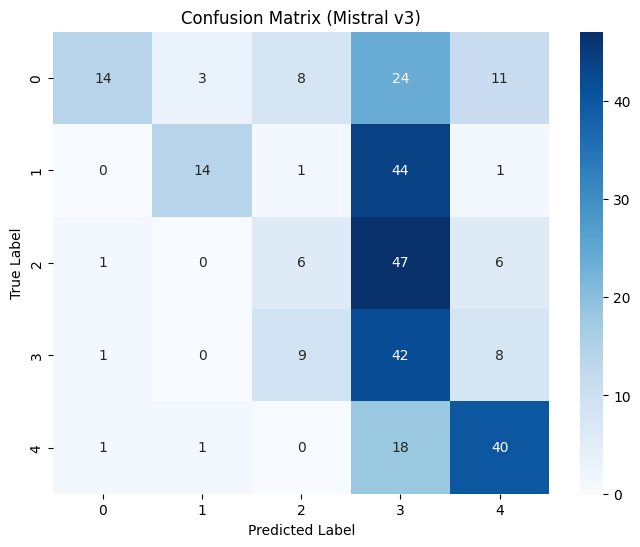

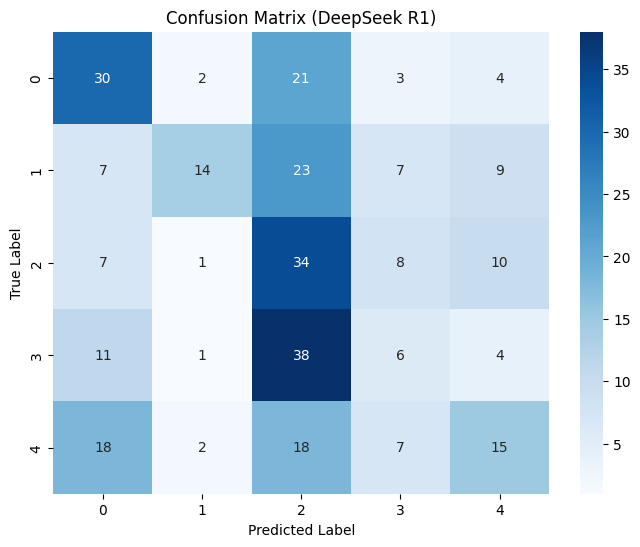


=== 2. Confusion Matrix Visualization Few Shot Setting ===


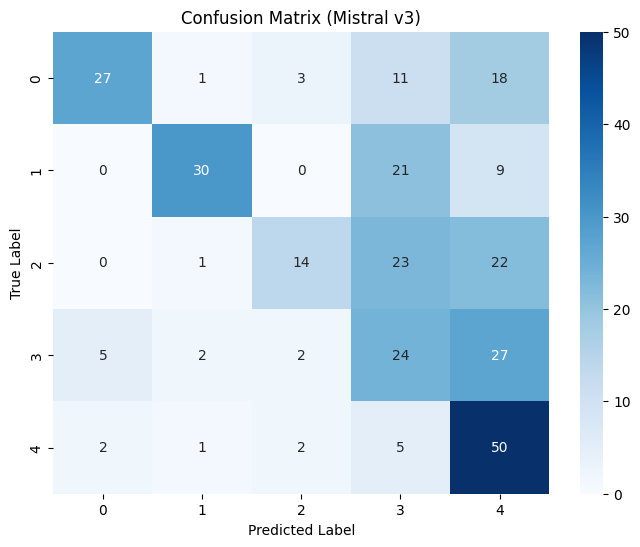

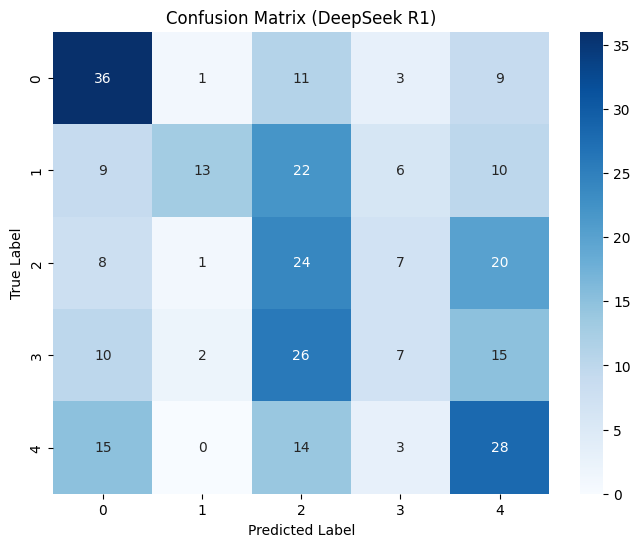


=== 3. MOST CONFUSED CLASS PAIRS  Few Shot Setting ===

Most confused class pairs in Mistral v3:
True 3 → Pred 4: 0.450
True 2 → Pred 3: 0.383
True 2 → Pred 4: 0.367
True 1 → Pred 3: 0.350
True 0 → Pred 4: 0.300

Most confused class pairs in DeepSeek R1
True 3 → Pred 2: 0.433
True 1 → Pred 2: 0.367
True 2 → Pred 4: 0.333
True 3 → Pred 4: 0.250
True 4 → Pred 0: 0.250

=== 4. Analysis of Specific Misclassified Samples Few Shot Setting ===
Total Mistral Misclassified Samples: 155 out of 300
--------------------------------------------------------------------------------
📄 Text: In my experience women don't recommend guys to their friends. If she doesn't want him then mostt likely other women don't
✅ True label: animosity | ❌ Predicted: prejudiced discussion
--------------------------------------------------------------------------------
📄 Text: And not imagine all those fans of Batchelorette. The packaged story that millions buy at zero thoughts of the sluttiness happening behind cameras

In [56]:
#Error analysis mistral v3
import matplotlib.pyplot as plt
import itertools
import seaborn as sns
from sklearn.metrics import confusion_matrix

target_names = [
    "not-sexist",   # 0
    "threats",      # 1
    "derogation",   # 2
    "animosity",    # 3
    "prejudiced discussion"    # 4
]

print("\n=== 1. Performance Metrics ===")
results = []

results.append({
    "Model": "Mistral v3",
    "Macro F1 zero-shot": f"{mistral_zero["macro_f1"]:.4f}",
    "Fail Ratio zero-shot": f"{mistral_zero["fail_ratio"]:.2%}",
    "Macro F1 few-shot": f"{mistral_few["macro_f1"]:.4f}",
    "Fail Ratio few-shot": f"{mistral_few["fail_ratio"]:.2%}"
})

results.append({
    "Model": "DeepSeek",
    "Macro F1 zero-shot": f"{deepseek_zero["macro_f1"]:.4f}",
    "Fail Ratio zero-shot": f"{deepseek_zero["fail_ratio"]:.2%}",
    "Macro F1 few-shot": f"{deepseek_few["macro_f1"]:.4f}",
    "Fail Ratio few-shot": f"{deepseek_few["fail_ratio"]:.2%}"
})

df_results = pd.DataFrame(results)
df_results = df_results.set_index("Model")
print(df_results)

print("\n=== 2. Confusion Matrix Visualization Zero Shot Setting ===")
#Mistral confusion matrix
cm_mistral = confusion_matrix(y_true, mistral_pred_labels_zero)
id_labels = ['0','1','2','3','4']
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mistral, annot=True, fmt='d', cmap='Blues',
            xticklabels= id_labels,
            yticklabels= id_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Mistral v3)')
plt.show()

#DeepSeek confusion matrix
cm_deepseek = confusion_matrix(y_true, deepseek_pred_labels_zero)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_deepseek, annot=True, fmt='d', cmap='Blues',
            xticklabels= id_labels,
            yticklabels= id_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (DeepSeek R1)')
plt.show()

print("\n=== 2. Confusion Matrix Visualization Few Shot Setting ===")
#Mistral confusion matrix
cm_mistral = confusion_matrix(y_true, mistral_predicted_labels)
id_labels = ['0','1','2','3','4']
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mistral, annot=True, fmt='d', cmap='Blues',
            xticklabels= id_labels,
            yticklabels= id_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Mistral v3)')
plt.show()

#DeepSeek confusion matrix
cm_deepseek = confusion_matrix(y_true, deepseek_predicted_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_deepseek, annot=True, fmt='d', cmap='Blues',
            xticklabels= id_labels,
            yticklabels= id_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (DeepSeek R1)')
plt.show()

print("\n=== 3. MOST CONFUSED CLASS PAIRS  Few Shot Setting ===")

cm_deep_norm = cm_deepseek / cm_deepseek.sum(axis=1, keepdims=True)
cm_mistral_norm = cm_mistral / cm_mistral.sum(axis=1, keepdims=True)

pairs_mistral = []
pairs_deep = []
for i, j in itertools.permutations(range(5), 2):
    pairs_deep.append(((i, j), cm_deep_norm[i, j]))
    pairs_mistral.append(((i,j), cm_mistral_norm[i,j]))

pairs_deep = sorted(pairs_deep, key=lambda x: x[1], reverse=True)
pairs_mistral = sorted(pairs_mistral, key=lambda x: x[1], reverse=True)
print("\nMost confused class pairs in Mistral v3:")
for (true_c, pred_c), score in pairs_mistral[:5]:
    print(f"True {true_c} → Pred {pred_c}: {score:.3f}")

print("\nMost confused class pairs in DeepSeek R1")
for (true_c, pred_c), score in pairs_deep[:5]:
    print(f"True {true_c} → Pred {pred_c}: {score:.3f}")

print("\n=== 4. Analysis of Specific Misclassified Samples Few Shot Setting ===")
#Mistral misclassification
y_true = np.array(y_true).flatten()
mistral_pred = np.array(mistral_predicted_labels).flatten()
mis_idx = np.where(mistral_pred!= y_true)[0]
print(f"Total Mistral Misclassified Samples: {len(mis_idx)} out of {len(y_true)}")
print("-" * 80)

for ((t, p),_) in pairs_mistral[:4]:
  mis_idx = np.where((y_true == t) & (mistral_pred == p))[0]
  for i in mis_idx[:3]:
    text_content = TEST_TEXTS[i]
    raw_response = mistral_raw_responses[i]

    true_label_name = target_names[y_true[i]]
    pred_label_name = target_names[mistral_pred[i]]

    print(f"📄 Text: {text_content}")
    print(f"✅ True label: {true_label_name} | ❌ Predicted: {pred_label_name}")
    print("-" * 80)

# DeepSeek misclassification
deepseek_pred = np.array(deepseek_predicted_labels).flatten()
mis_idx = np.where(deepseek_pred!= y_true)[0]
print(f"Total DeepSeek Misclassified Samples: {len(mis_idx)} out of {len(y_true)}")

print("-" * 80)
for ((t, p),_) in pairs_deep[:4]:
  mis_idx = np.where((y_true == t) & (deepseek_pred == p))[0]
  for i in mis_idx[:3]:
    text_content = TEST_TEXTS[i]
    raw_response = deepseek_raw_responses[i]

    true_label_name = target_names[y_true[i]]
    pred_label_name = target_names[deepseek_pred[i]]

    print(f"📄 Text: {text_content}")
    print(f"✅ True label: {true_label_name} | ❌ Predicted: {pred_label_name}")
    print(f"📝 Model output: {raw_response}")

    print("-" * 80)


**1. Review of Results and Common Errors**\
The confusion matrix analysis in both zero-shot and few-shot settings shows that both models benefit from in-context learning, with fewer systematic misclassifications in the few-shot regime. In particular, few-shot prompting leads to a more balanced distribution of predictions across classes and reduces the overclassification of specific labels, namely ANIMOSITY for Mistral and DEROGATION for DeepSeek R1.
Mistral v3 tends to rely heavily on lexical cues when assigning labels, often confusing ANIMOSITY and DEROGATION in the presence of strong negative terms (e.g., "hate"). \
It more frequently predicts PREJUDICED DISCUSSION when the text contains stereotypes or generalized statements, whereas ANIMOSITY is preferred when aggressive language is present, independently of the broader context. For example, the sentence "Don't misunderstand me, I love my mother to death. At the same time, I would also like to give her a few slaps due to her meddling in my affairs" is labeled as ANIMOSITY, despite containing an implicit threat that is not correctly detected.\
In cases where the predicted label is DEROGATION while the true label is THREAT, DeepSeek shows difficulty handling mixed signals involving threats and hate expressions, assigning greater weight to hateful language. Additionally, DeepSeek exhibits a conservative bias, frequently defaulting to the majority class NON-SEXIST.\
Overall, Mistral v3 achieves better performance, potentially due to architectural differences and stronger instruction-following optimization.

